# Causal saliency smoke test (v4.3 hybrid)

Interactive smoke test for the causal-attribution primitives in
`causal_saliency_hybrid.py`. Targets the v4.3 hybrid CNN+GNN checkpoint, but
**does not** run a full sweep: the v4.3 dataset split has a known fatal
species-leak issue, so its embeddings/predictions are not trustworthy for
publication. The purpose of this notebook is to:

1. Verify the model loads and reproduces logged predictions on a handful of
   sequences.
2. Verify each attribution primitive (saliency, IG, occlusion in N/shuffle/
   reverse modes, sufficiency keep-only, deletion curve) returns finite,
   sensible outputs.
3. Demonstrate the `saliency vs occlusion` correlation diagnostic on ~10
   sequences, just to confirm the metric is well-defined.

When a properly-split model becomes available, swap the checkpoint path in
cell 3 — the rest of the pipeline does not change.

**MPS note:** all execution stays inside this kernel (no `nohup`/background)
because MPS has shown intermittent kernel-launch issues when run from a
background shell.

In [1]:
import os, sys, json
import numpy as np
import torch

# Resolve repo root: the notebook lives in <repo>/model_result_interp/.
NB_DIR = os.path.dirname(os.path.abspath("__file__")) if False else os.getcwd()
# When the notebook is opened in-place its cwd is the notebook directory;
# when run from elsewhere we fall back to walking up until we find data/vgp.
def _find_repo(start: str) -> str:
    p = os.path.abspath(start)
    for _ in range(6):
        if os.path.isdir(os.path.join(p, "data", "vgp")):
            return p
        p = os.path.dirname(p)
    raise RuntimeError(f"could not locate repo root from {start}")
REPO = _find_repo(NB_DIR)
NB_DIR = os.path.join(REPO, "model_result_interp")
if NB_DIR not in sys.path:
    sys.path.insert(0, NB_DIR)
import causal_saliency_hybrid as csh
print("repo:", REPO)
CKPT = os.path.join(REPO, "data_analysis", "vgp_model_data_tpase_multi", "v4.3",
                    "hybrid_v4.3_epoch40.pt")
LABELS_TSV = os.path.join(REPO, "model_result_interp", "interpretation_results",
                          "causal_saliency_hybrid", "labels.tsv")
FASTA = os.path.join(REPO, "data", "vgp", "all_vgp_tes.fa")
PRED_CSV = os.path.join(REPO, "data_analysis", "vgp_model_data_tpase_multi",
                        "v4.3", "all_test_predictions_v4.3.csv")

device = csh.resolve_device()
print("device:", device)
assert os.path.exists(LABELS_TSV), (
    f"Missing labels TSV: {LABELS_TSV}\n"
    "Run `./.venv/bin/python model_result_interp/preprocess_labels.py` first."
)

repo: /Users/alexyang/Documents/Part III System Biology/TE Classification
device: mps


## 1. Load checkpoint and label TSV

In [2]:
model, class_names, sf_names = csh.load_hybrid_checkpoint(CKPT, device)
print(f"loaded v4.3: {len(class_names)} classes, {len(sf_names)} superfamilies")

# Load preprocessed labels (no FASTA parsing here).
import csv
rows = list(csv.DictReader(open(LABELS_TSV), delimiter="\t"))
print(f"labels rows: {len(rows)}")
usable = [r for r in rows if r["in_model_vocab"] == "1" and r["tir"] in ("0","1")]
print(f"usable (in v4.3 vocab + has tir flag): {len(usable)}")

loaded v4.3: 3 classes, 23 superfamilies
labels rows: 135751
usable (in v4.3 vocab + has tir flag): 10253


## 2. Validate forward pass against logged predictions

We pick 12 distinct superfamilies from the published `all_test_predictions_v4.3.csv`,
load their sequences via the random-access FASTA offsets, and verify our
re-built model reproduces the logged predicted IDs exactly.

In [3]:
header_to_row = {r["header"]: r for r in rows}

import csv as _csv
seen_sf, samples = set(), []
with open(PRED_CSV) as f:
    for r in _csv.DictReader(f):
        sf = int(r["true_superfamily_id"])
        if sf in seen_sf: continue
        if r["header"] not in header_to_row: continue
        samples.append(r); seen_sf.add(sf)
        if len(samples) >= 12: break
print(f"picked {len(samples)} sample rows from prediction CSV")

def load_seq(header):
    meta = header_to_row[header]
    with open(FASTA, "rb") as f:
        f.seek(int(meta["fa_offset"]))
        chunk = f.read(int(meta["fa_byte_len"])).decode("ascii")
    lines = chunk.split("\n")
    return "".join(lines[1:]).upper()

encs = [csh.encode_sequence(load_seq(r["header"]), r["header"]) for r in samples]
featurizer = csh.KmerFeaturizer()
sf_logits = csh.predict_logits(model, encs, featurizer, device,
                               batch_size=8, head=csh.HEAD_SUPERFAMILY)
ours_pred = sf_logits.argmax(axis=1)
ok = sum(int(p) == int(r["pred_superfamily_id"]) for p, r in zip(ours_pred, samples))
print(f"superfamily prediction agreement: {ok}/{len(samples)}")
for r, p in zip(samples, ours_pred):
    flag = "OK" if int(p) == int(r["pred_superfamily_id"]) else "MISS"
    print(f"  [{flag}] {r['header'][:55]:55s} csv={sf_names[int(r['pred_superfamily_id'])]:22s} ours={sf_names[int(p)]}")
assert ok >= len(samples) - 1, "Forward reconstruction broken — bail."

picked 12 sample rows from prediction CSV
superfamily prediction agreement: 12/12
  [OK] Rex-Babar_7-fCarCar#LINE/Rex-Babar                      csv=LINE/Rex-Babar         ours=LINE/Rex-Babar
  [OK] ERV3_3-bHirRus#LTR/ERV3                                 csv=LTR/ERV3               ours=LTR/ERV3
  [OK] L1_30-aDenEbr#LINE/L1                                   csv=LINE/L1                ours=LINE/L1
  [OK] CR1_22-rPodFil#LINE/CR1                                 csv=LINE/CR1               ours=LINE/CR1
  [OK] DIRS_608-aBomVar#LTR/DIRS                               csv=LTR/DIRS               ours=LTR/DIRS
  [OK] Gypsy_120-fNotCoa#LTR/Gypsy                             csv=LTR/Gypsy              ours=LTR/Gypsy
  [OK] L2_1-rAnoSag#LINE/L2                                    csv=LINE/L2                ours=LINE/L2
  [OK] TcMar-Tc1_4-fCheLab#DNA/TcMar-Tc1                       csv=LINE/Rex-Babar         ours=LINE/Rex-Babar
  [OK] ERV1_22-sScyCan#LTR/ERV1                                csv=LTR/ERV1

## 3. Attribution primitives on a single sequence

Pick the most-confident sequence from above, compute every primitive, print
shapes and finite-ness.

In [4]:
import time
e = encs[0]
target_sf = int(ours_pred[0])
print(f"target sequence: {e.header[:60]!r}, length={e.length}, target sf id={target_sf} ({sf_names[target_sf]})")

t = time.time()
sal = csh.compute_saliency(model, e, target_sf, featurizer, device, head=csh.HEAD_SUPERFAMILY)
print(f"saliency: shape={sal.shape}, finite={np.isfinite(sal).all()}, |.|.mean={np.abs(sal).mean():.3e}, t={time.time()-t:.2f}s")

t = time.time()
ig = csh.compute_integrated_gradients(model, e, target_sf, featurizer, device, steps=8, head=csh.HEAD_SUPERFAMILY)
print(f"IG (8 steps): shape={ig.shape}, finite={np.isfinite(ig).all()}, |.|.mean={np.abs(ig).mean():.3e}, t={time.time()-t:.2f}s")

target sequence: 'Rex-Babar_7-fCarCar#LINE/Rex-Babar', length=3431, target sf id=14 (LINE/Rex-Babar)
saliency: shape=(20000,), finite=True, |.|.mean=4.560e-04, t=3.50s
IG (8 steps): shape=(20000,), finite=True, |.|.mean=1.271e-03, t=0.22s


In [5]:
t = time.time()
occN = csh.occlusion_profile(model, e, [target_sf], featurizer, device,
                             window=200, stride=200, mode="N", batch_size=8,
                             head=csh.HEAD_SUPERFAMILY)
occS = csh.occlusion_profile(model, e, [target_sf], featurizer, device,
                             window=200, stride=200, mode="shuffle", batch_size=8,
                             head=csh.HEAD_SUPERFAMILY)
occR = csh.occlusion_profile(model, e, [target_sf], featurizer, device,
                             window=200, stride=200, mode="reverse", batch_size=8,
                             head=csh.HEAD_SUPERFAMILY)
for name, occ in [("N", occN), ("shuffle", occS), ("reverse", occR)]:
    d = occ["drops"][0]
    print(f"occlusion {name:7s}: positions={d.size}, drop range=[{d.min():+.3f}, {d.max():+.3f}], mean={d.mean():+.3f}")
print(f"  total occlusion time: {time.time()-t:.2f}s")

occlusion N      : positions=17, drop range=[-0.076, +0.023], mean=-0.037
occlusion shuffle: positions=17, drop range=[-0.157, +0.039], mean=-0.038
occlusion reverse: positions=17, drop range=[-0.026, +0.014], mean=-0.003
  total occlusion time: 0.79s


In [6]:
t = time.time()
suf = csh.keep_only_window_profile(model, e, [target_sf], featurizer, device,
                                   window=600, stride=300, batch_size=8,
                                   head=csh.HEAD_SUPERFAMILY)
print(f"sufficiency (keep-only 600bp): logit range=[{suf['survived'][0].min():+.3f}, {suf['survived'][0].max():+.3f}], n_windows={suf['survived'].shape[1]}, t={time.time()-t:.2f}s")

t = time.time()
dc = csh.deletion_curve(model, e, sal, target_sf, featurizer, device,
                        n_steps=8, head=csh.HEAD_SUPERFAMILY)
print(f"deletion curve: AUC saliency={dc['auc_saliency']:.3f}, AUC random={dc['auc_random']:.3f}, gap (rand-sal)={dc['auc_gap']:+.3f}, t={time.time()-t:.2f}s")

sufficiency (keep-only 600bp): logit range=[-1.801, -1.555], n_windows=10, t=0.45s
deletion curve: AUC saliency=0.429, AUC random=-0.287, gap (rand-sal)=-0.716, t=0.33s


## 4. Saliency↔occlusion correlation on ~10 sequences

This is the diagnostic Hadi asked for: how well does gradient-based saliency
correspond to actual causal effect (= what happens when we occlude)?

We use Spearman ρ on per-window means.

**Caveat (v4.3 unreliable):** because the v4.3 split has species leakage,
ρ values here are reported for **infrastructure validation only** — they
should not be put into the thesis. Re-run when a properly-split model is
ready.

In [7]:
import time
records = []
t0 = time.time()
for i, en in enumerate(encs[:10]):
    target = int(ours_pred[i])
    s = csh.compute_saliency(model, en, target, featurizer, device, head=csh.HEAD_SUPERFAMILY)
    o_N = csh.occlusion_profile(model, en, [target], featurizer, device,
                                window=200, stride=200, mode="N", batch_size=8,
                                head=csh.HEAD_SUPERFAMILY)
    o_S = csh.occlusion_profile(model, en, [target], featurizer, device,
                                window=200, stride=200, mode="shuffle", batch_size=8,
                                head=csh.HEAD_SUPERFAMILY)
    o_R = csh.occlusion_profile(model, en, [target], featurizer, device,
                                window=200, stride=200, mode="reverse", batch_size=8,
                                head=csh.HEAD_SUPERFAMILY)
    records.append(dict(
        header=en.header,
        sf=sf_names[target],
        rho_N=csh.saliency_occlusion_correlation(s, o_N),
        rho_shuffle=csh.saliency_occlusion_correlation(s, o_S),
        rho_reverse=csh.saliency_occlusion_correlation(s, o_R),
        n_windows=int(o_N["drops"].shape[1]),
    ))
    print(f"  [{i+1}/10] {en.header[:50]:50s} ρ_N={records[-1]['rho_N']:+.3f} "
          f"ρ_S={records[-1]['rho_shuffle']:+.3f} ρ_R={records[-1]['rho_reverse']:+.3f}")
print(f"total: {time.time()-t0:.1f}s")

  [1/10] Rex-Babar_7-fCarCar#LINE/Rex-Babar                 ρ_N=+0.333 ρ_S=-0.331 ρ_R=-0.071
  [2/10] ERV3_3-bHirRus#LTR/ERV3                            ρ_N=+0.418 ρ_S=+0.195 ρ_R=-0.167
  [3/10] L1_30-aDenEbr#LINE/L1                              ρ_N=+0.281 ρ_S=+0.311 ρ_R=+0.254
  [4/10] CR1_22-rPodFil#LINE/CR1                            ρ_N=-0.150 ρ_S=+0.174 ρ_R=-0.179
  [5/10] DIRS_608-aBomVar#LTR/DIRS                          ρ_N=-0.408 ρ_S=+0.166 ρ_R=+0.249
  [6/10] Gypsy_120-fNotCoa#LTR/Gypsy                        ρ_N=+0.111 ρ_S=+0.300 ρ_R=-0.202
  [7/10] L2_1-rAnoSag#LINE/L2                               ρ_N=+0.426 ρ_S=+0.169 ρ_R=+0.360
  [8/10] TcMar-Tc1_4-fCheLab#DNA/TcMar-Tc1                  ρ_N=-0.321 ρ_S=+0.321 ρ_R=-0.236
  [9/10] ERV1_22-sScyCan#LTR/ERV1                           ρ_N=+0.057 ρ_S=+0.179 ρ_R=+0.012
  [10/10] DIRS_1-bAytFer#LTR                                 ρ_N=+0.016 ρ_S=-0.270 ρ_R=+0.076
total: 12.0s


In [8]:
import numpy as np
def summarize(key):
    vals = np.array([r[key] for r in records], dtype=float)
    vals = vals[np.isfinite(vals)]
    if vals.size == 0:
        return f"{key}: all-NaN"
    return (f"{key}: median={np.median(vals):+.3f}, mean={vals.mean():+.3f}, "
            f"n_pos={(vals>0).sum()}, n_neg={(vals<0).sum()}")

for k in ("rho_N", "rho_shuffle", "rho_reverse"):
    print(summarize(k))
print()
print("Caveat: v4.3 has species leakage; treat these numbers as smoke-test "
      "validation, NOT scientific evidence. Re-run on a properly-split "
      "model.")

rho_N: median=+0.084, mean=+0.076, n_pos=7, n_neg=3
rho_shuffle: median=+0.176, mean=+0.121, n_pos=8, n_neg=2
rho_reverse: median=-0.030, mean=+0.009, n_pos=5, n_neg=5

Caveat: v4.3 has species leakage; treat these numbers as smoke-test validation, NOT scientific evidence. Re-run on a properly-split model.


## 5. (Optional) Visualise one example

A single overlay plot of saliency vs occlusion drops vs sequence position.

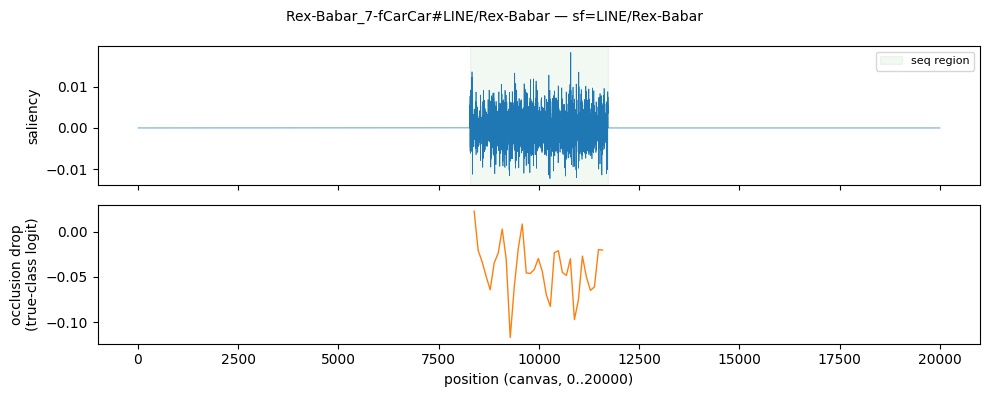

In [9]:
import matplotlib.pyplot as plt

i = 0
en = encs[i]
target = int(ours_pred[i])
s = csh.compute_saliency(model, en, target, featurizer, device, head=csh.HEAD_SUPERFAMILY)
o = csh.occlusion_profile(model, en, [target], featurizer, device,
                          window=200, stride=100, mode="N", batch_size=8,
                          head=csh.HEAD_SUPERFAMILY)

fig, axes = plt.subplots(2, 1, figsize=(10, 4), sharex=True)
axes[0].plot(np.arange(len(s)), s, lw=0.5)
axes[0].set_ylabel("saliency")
axes[0].axvspan(en.start, en.end, alpha=0.05, color="green", label="seq region")
axes[0].legend(loc="upper right", fontsize=8)
axes[1].plot(o["centers"], o["drops"][0], lw=1.0, color="C1")
axes[1].set_ylabel("occlusion drop\n(true-class logit)")
axes[1].set_xlabel("position (canvas, 0..20000)")
fig.suptitle(f"{en.header[:60]} — sf={sf_names[target]}", fontsize=10)
plt.tight_layout()
plt.show()

## Summary

| check | status |
|---|---|
| preprocessed labels TSV exists | passes if cell 2 didn't AssertionError |
| forward reproduces logged preds | requires `>=11/12` agreement in cell 4 |
| saliency / IG finite | cell 5 |
| occlusion N/shuffle/reverse finite | cell 6 |
| sufficiency + deletion finite | cell 7 |
| ρ batch runs end-to-end | cell 9 |

If everything above passes, the infrastructure is correct. Do **not** scale
this up to a full sweep on v4.3 — wait for the post-split-fix checkpoint.